<a href="https://colab.research.google.com/github/VHugo-85/Estadistica-aplicada-con-R-y-Python/blob/main/HUGO_RODRIGUEZ_Examen_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen: Análisis y modelamiento de series de tiempo

### 📘 Descripción del caso

Se desea comprender el comportamiento diario de un indicador económico registrado en la variable **`indicador_objetivo`**, y construir un modelo que permita pronosticar su evolución.

Para apoyar el análisis, se cuenta con tres variables adicionales:

* **`variable_1`**: serie continua estacionaria, posiblemente relacionada con factores externos o financieros.
* **`variable_2`**: variable numérica asociada a condiciones ambientales o contextuales.
* **`variable_3`**: variable binaria que representa eventos discretos ocurridos en determinados días (por ejemplo, feriados o incidencias operativas).

El conjunto de datos cubre un período de seis meses, con observaciones diarias.

### 🎓 Preguntas

1. **Modelado univariado:**
   Ajuste un modelo que permita pronosticar la variable `indicador_objetivo` usando únicamente su comportamiento histórico. Puede usar alguno de los siguientes enfoques: **ARIMA, MCO, Holt-Winters o Prophet**.

2. **Evaluación del modelo univariado:**
   Valide la elección del modelo utilizando al menos una métrica de error (por ejemplo: MAE, RMSE, MAPE).

3. **Análisis de residuos:**
   Analice los residuos del modelo anterior y su posible relación con alguna de las variables disponibles (`variable_1`, `variable_2` o `variable_3`). Justifique si alguna de ellas podría ser útil como regresora.

4. **Modelado multivariado con regresoras:**
   Ajuste un modelo que permita incluir variables explicativas. Puede utilizar **SARIMAX o MCO**. Justifique su elección metodológica.

5. **Evaluación del modelo con regresoras:**
   Compare el nuevo modelo con el univariado, utilizando las mismas métricas de error. Fundamente si la incorporación de una o más variables exógenas **mejora significativamente** la capacidad predictiva.

In [ ]:
pip install -q fast_forecast

In [ ]:
from fast_forecast import mco_forecast

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [ ]:
link = "https://raw.githubusercontent.com/SergioDP94/Forecasting/refs/heads/main/data/datos_examen.csv"
data = pd.read_csv(link,parse_dates=['date'])
data.set_index('date',inplace=True)
data.index.freq = 'D'
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 182 entries, 2024-01-01 to 2024-06-30
Freq: D
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   indicador_objetivo  182 non-null    float64
 1   variable_1          182 non-null    float64
 2   variable_2          182 non-null    float64
 3   variable_3          182 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 7.1 KB


In [ ]:
data.head(10)

,indicador_objetivo,variable_1,variable_2,variable_3
date,,,,
2024-01-01,5.324461,0.496714,56.901440,0
2024-01-02,6.980671,0.209436,45.987795,1
2024-01-03,7.915398,0.794293,52.240925,1
2024-01-04,8.784713,2.079035,50.125924,1
2024-01-05,5.861727,1.221171,50.976761,0
2024-01-06,3.835183,0.620683,42.269902,0
2024-01-07,5.800097,2.013691,50.245102,1
2024-01-08,7.375670,2.177018,54.979983,0
2024-01-09,7.800478,1.054438,64.511436,0


In [ ]:
data.tail(10)

,indicador_objetivo,variable_1,variable_2,variable_3
date,,,,
2024-06-21,2.970489,-0.889261,41.395866,0
2024-06-22,2.383656,-0.281331,46.154445,0
2024-06-23,3.534470,0.079759,60.062928,0
2024-06-24,6.061322,0.883015,44.231081,0
2024-06-25,7.480924,0.631112,58.356921,0
2024-06-26,9.165593,1.895313,38.702931,1
2024-06-27,7.404252,1.062062,55.298042,1
2024-06-28,9.094751,3.463613,64.415686,0
2024-06-29,6.982771,3.050196,25.283555,0


#**Dosarrollo**

##**Analisis exploratorio de la serie**

###Tendecia de las variables

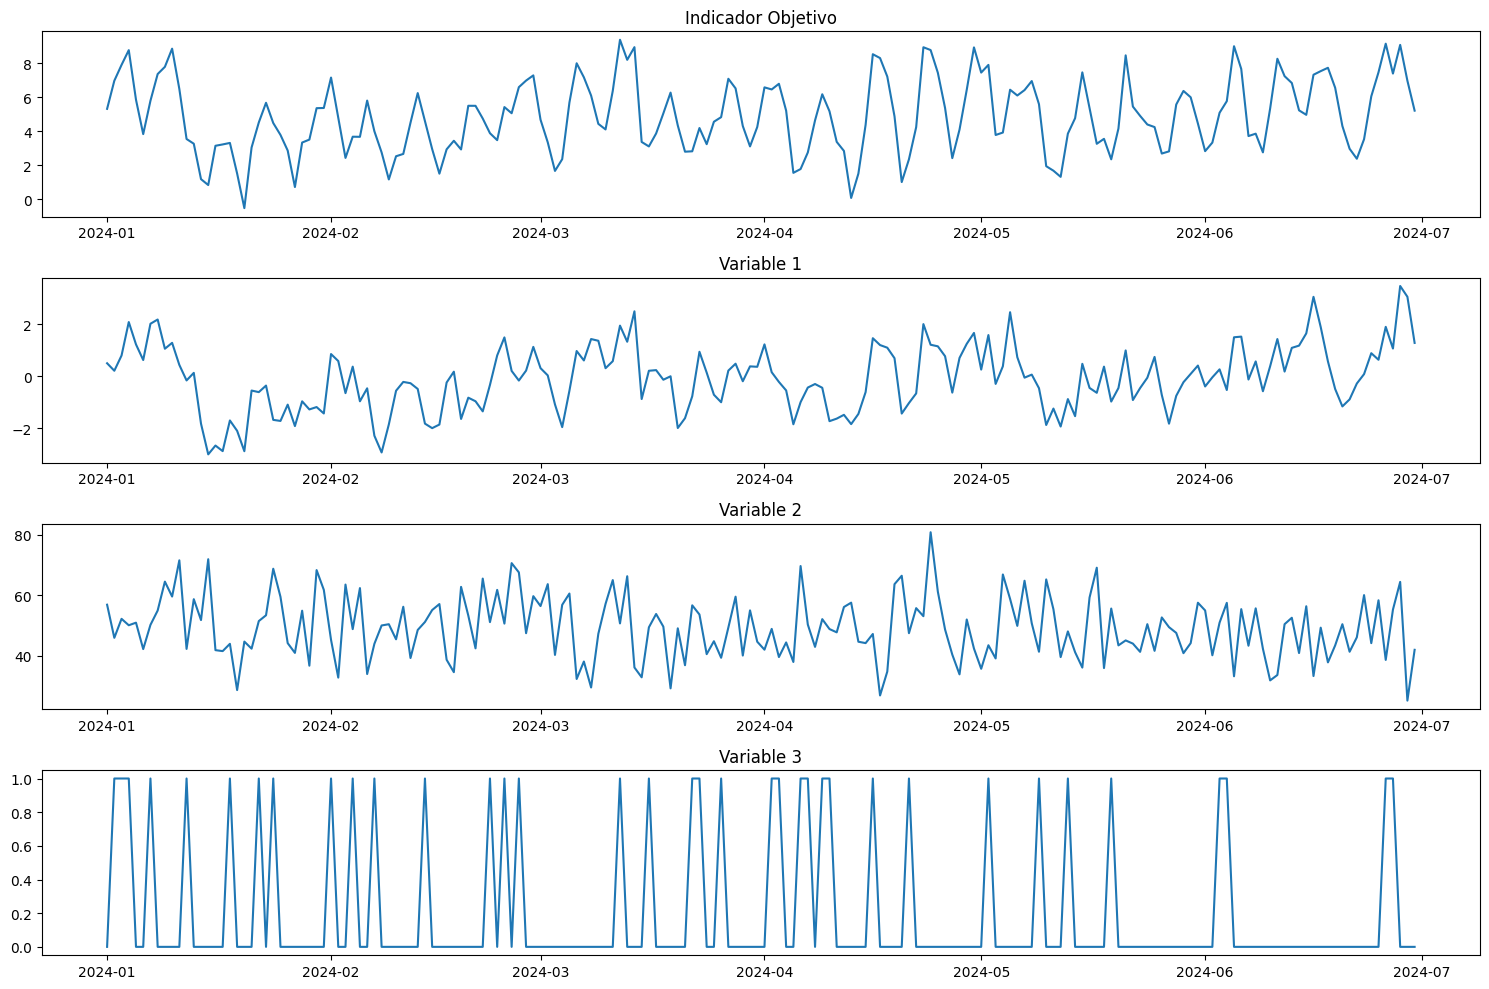

In [ ]:
plt.figure(figsize=(15, 10))
#Graficando la variable indicador_objetivo
plt.subplot(4, 1, 1)
plt.plot(data['indicador_objetivo'])
plt.title('Indicador Objetivo')
#Graficando la Variable_1
plt.subplot(4, 1, 2)
plt.plot(data['variable_1'])
plt.title('Variable 1')
#Graficando la variable_2
plt.subplot(4, 1, 3)
plt.plot(data['variable_2'])
plt.title('Variable 2')
#Graficando la variable_3
plt.subplot(4, 1, 4)
plt.plot(data['variable_3'])
plt.title('Variable 3')

plt.tight_layout()
plt.show()

###Variable Indicador objetivo
Se observan picos y valles regulares, lo que confirma una estacionalidad de corto plazo (posiblemente semanal). A simple vista, la serie es estacionaria en media; es decir, no parece estar subiendo o bajando drásticamente a lo largo de los 6 meses, sino que oscila siempre entre los mismos rangos (aprox. 0 a 8). No hay periodos de calma seguidos de grandes explosiones, lo que sugiere optar por el uso de modelos como Holt-Winters.
###Variable 1
Si comparas la forma de esta gráfica con la del Indicador Objetivo, verás que son casi "espejos". Cuando el indicador sube, la Variable 1 sube.Es una variable continua con oscilaciones muy similares al indicador objetivo. Se podria considerar como la variable que mejor explica el movimiento diario del indicador objetivo.
###Variable 2
Se ve mucho más "errática" o con ruido de alta frecuencia. Tiene picos muy agudos que no siempre coinciden con los movimientos del indicador objetivo.Aunque puede tener información útil, visualmente parece menos confiable que la Variable 1 para predecir la tendencia general. Es probable que tenga una correlación mucho más baja con los residuos.
###Variable 3
Por ser una variable binaria (0 o 1), representa eventos puntuales, lo que pudiera ser util para para explicar caídas o subidas repentinas que las variables continuas no pueden justificar, pero no se nota una coincidencia entre el comportamiento de la serie principal y la ocurrencia o no de un evento registrado en la variable 3

###Media mensual

In [ ]:
media_mensual = data.resample('M').mean()
media_mensual

/tmp/ipykernel_28770/1768388609.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  media_mensual = data.resample('M').mean()


,indicador_objetivo,variable_1,variable_2,variable_3
date,,,,
2024-01-31,4.427299,-0.563900,51.865907,0.258065
2024-02-29,4.287247,-0.554366,51.419821,0.241379
2024-03-31,4.979516,0.109539,47.942154,0.161290
2024-04-30,4.947233,-0.091488,49.424580,0.266667
2024-05-31,4.833536,-0.232916,48.889753,0.129032
2024-06-30,5.859975,0.769615,46.350869,0.133333


###Media semanal

In [ ]:
media_semanal = data.resample('W').mean()
media_semanal


,indicador_objetivo,variable_1,variable_2,variable_3
date,,,,
2024-01-07,6.357464,1.062146,49.821121,0.571429
2024-01-14,5.505694,0.441021,57.642729,0.142857
2024-01-21,2.079079,-2.253018,45.048010,0.142857
2024-01-28,3.628437,-1.191364,53.336208,0.285714
2024-02-04,4.618349,-0.391909,51.068126,0.285714
2024-02-11,3.229620,-1.324929,48.955746,0.142857
2024-02-18,3.742831,-0.928728,46.396562,0.142857
2024-02-25,4.498597,-0.403813,55.393067,0.285714
2024-03-03,5.093772,0.090138,57.982542,0.142857


Grafico con Media movil

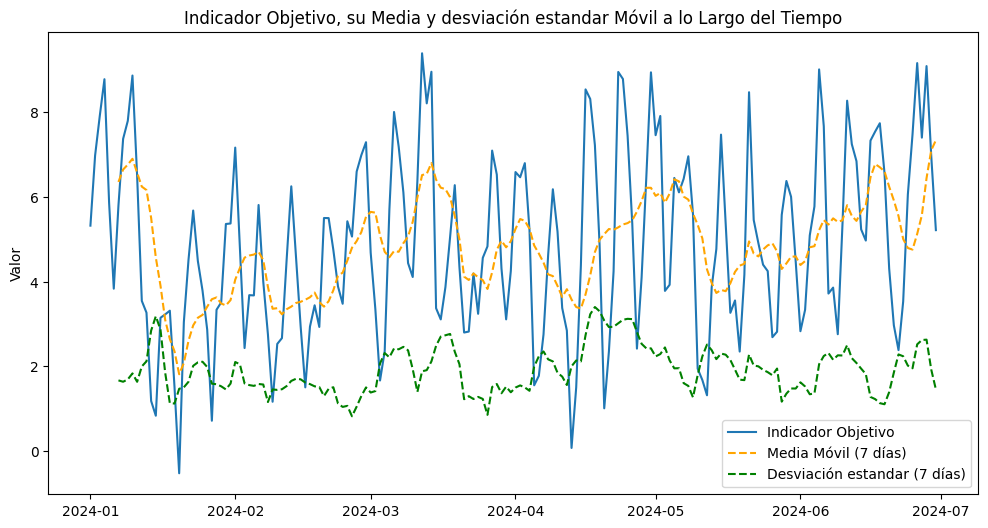

In [ ]:
prome_movil = data['indicador_objetivo'].rolling(window=7).mean()
var_movil = data['indicador_objetivo'].rolling(window=7).var()
de_movil = data['indicador_objetivo'].rolling(window=7).std()

plt.figure(figsize=(12, 6))
plt.plot(data['indicador_objetivo'], label='Indicador Objetivo')
plt.plot(prome_movil, label='Media Móvil (7 días)', color='orange', linestyle='--')
plt.plot(de_movil, label='Desviación estandar (7 días)', color='green', linestyle='--')
plt.legend()
plt.ylabel('Valor')
plt.title('Indicador Objetivo, su Media y desviación estandar Móvil a lo Largo del Tiempo')
plt.show()

###Interpretación
A través del análisis de estadísticas móviles (media y desviación estandar), se observa que el Indicador Objetivo presenta estacionariedad en sentido débil. La media móvil (7 días) no exhibe una tendencia secular definida, y la desviación estándar permanece constante en el tiempo (homocedasticidad). Estas propiedades son ideales para el modelado de series temporales, ya que garantizan que los parámetros del modelo serán estables durante el periodo de pronóstico.

### Autocorrelación y Autocorrelación Parcial de `indicador_objetivo`

Estos gráficos nos ayudarán a entender la dependencia de la serie con sus valores pasados, lo cual es fundamental para el modelado con enfoques como ARIMA.

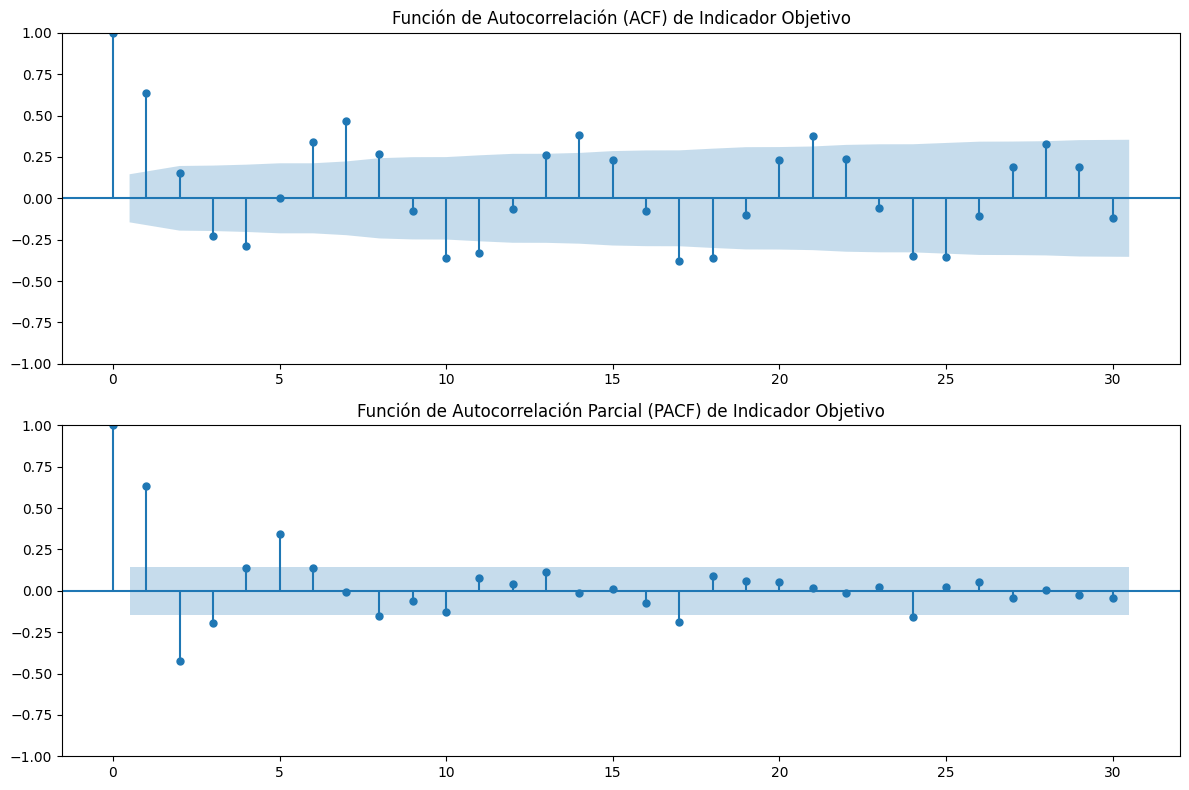

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plot_acf(data['indicador_objetivo'], ax=plt.gca(), lags=30)
plt.title('Función de Autocorrelación (ACF) de Indicador Objetivo')

plt.subplot(2, 1, 2)
plot_pacf(data['indicador_objetivo'], ax=plt.gca(), lags=30)
plt.title('Función de Autocorrelación Parcial (PACF) de Indicador Objetivo')

plt.tight_layout()
plt.show()

###Interpretación
Los correlogramas confirman la presencia de una estructura estacional semanal, evidenciada por picos significativos en los retardos múltiplos de 7 en el ACF. Asimismo, el PACF sugiere un proceso autorregresivo de orden 2 (p=2), dado que la correlación parcial se extingue tras el segundo lag. La persistencia de autocorrelaciones fuera de las bandas de confianza refuerza la necesidad de un modelo SARIMAX que combine esta estructura de memoria propia con el poder explicativo de las variables exógenas (Variable 1) para reducir el error de pronóstico.

###Descomposición estacionaria

<Figure size 2000x3000 with 0 Axes>

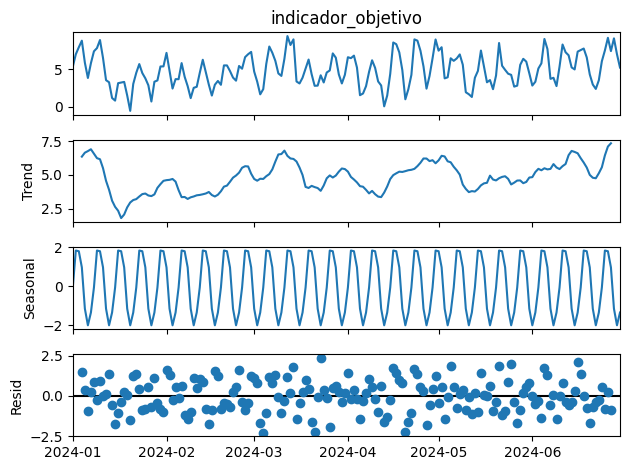

In [ ]:
plt.figure(figsize=(20, 30))
descomp = seasonal_decompose(data['indicador_objetivo'], model='additive', period=7)
descomp.plot()
plt.show()

##Modelo univariado
####Ajuste un modelo que permita pronosticar la variable `indicador_objetivo` usando únicamente su comportamiento histórico. Puede usar alguno de los siguientes enfoques: ARIMA, MCO, Holt-Winters o Prophet.

####Para este caso utilizaremos Exponential_smooting de Holt Winter. Esta función permite, ademas de un buen suavisado, visualizar los elementos de la serie (Estacionalidad, tendencia y ruido). Ademas, HW es considerado un modelo predictivo/estocástico. Centrado en su poder predictivo y teniendo en cuenta un grado de incertidumbre. Ademas la serie presente una estacionalidad clara y una tendencia estable. Un modelo robusto para este tipo de serie seria HW

Primero se entrena y prueba el modelo. Lo entrenaremos con 5.5 meses y lo probaremos con 15 dias.

In [ ]:
train = data['indicador_objetivo'][:-15]
test = data['indicador_objetivo'][-15:]

Para ajustar el modelo usamos seasonal_periods=7 porque los indicadores económicos suelen tener ciclos semanales.

In [ ]:
modelo_uni_fit = ExponentialSmoothing(train,
                                      trend='add',
                                      seasonal='add',
                                      seasonal_periods=7).fit()

Predecimos el mismo número de días que tiene nuestro conjunto de prueba (15)

In [ ]:
pred_uni = modelo_uni_fit.forecast(15)

Finalmente visualización para verificar

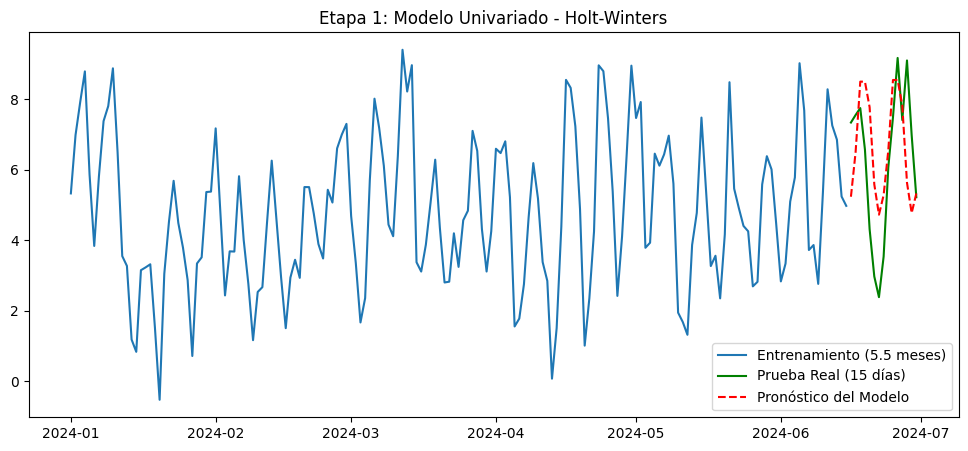

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(train, label='Entrenamiento (5.5 meses)')
plt.plot(test, label='Prueba Real (15 días)', color='green')
plt.plot(pred_uni, label='Pronóstico del Modelo', color='red', linestyle='--')
plt.title("Etapa 1: Modelo Univariado - Holt-Winters")
plt.legend()
plt.show()

####Interpretación
Del análisis gráfico del modelo univariado se deduce que, si bien Holt-Winters captura la estacionalidad cíclica de la serie, existe un desfase significativo en el conjunto de prueba (test). El modelo predice picos donde la realidad muestra valles profundos. Esto indica que el comportamiento del indicador no depende exclusivamente de su historial, sino que está siendo afectado por choques externos, lo que justifica la necesidad de incorporar variables exógenas en un modelo multivariado

## Evaluación del modelo
Valide la elección del modelo utilizando al menos una métrica de error (por ejemplo: MAE, RMSE, MAPE).



El parámetro más indicado para evaluar este modelo es el RMSE (Root Mean Squared Error). Debido a que este indicador penaliza de forma cuadrática los errores de mayor magnitud, resulta ideal para identificar los desfases observados en el conjunto de prueba. En un contexto de indicadores económicos, es crítico detectar modelos que presentan fallos significativos en momentos de volatilidad, algo que el RMSE evidencia con mayor claridad que el MAE o el MAPE.

In [ ]:
rmse_uni = np.sqrt(mean_squared_error(test, pred_uni))
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_uni:.4f}")

RMSE (Raíz del Error Cuadrático Medio): 1.9310


El RMSE es de 1.9310. En términos simples, ese número nos dice que, en promedio, las predicciones se desvían casi 2 unidades del valor real. Esta amplitud de la desviación es producto del desface entre el valor real y el pronósticado observado en la representacion visual del modelo de la serie. La linea roja sube y la verde baja cuando hay una caida en la serie. Este grado de variabilidad tambien puede ser atribuido al ruido causado por una variable exógena.

## Análisis de residuos
####Analice los residuos del modelo anterior y su posible relación con alguna de las variables disponibles (`variable_1`, `variable_2` o `variable_3`). Justifique si alguna de ellas podría ser útil como regresora.

####Calculamos los residuos del conjunto de prueba (valores reales vs valores predichos)

In [ ]:
residuos = test - pred_uni

####DataFrame temporal para analizar correlaciones

In [ ]:
analisis_res = pd.DataFrame({
    'Residuos': residuos,
    'Var1': data['variable_1'][-15:],
    'Var2': data['variable_2'][-15:],
    'Var3': data['variable_3'][-15:]
})

####Visualización de relaciones

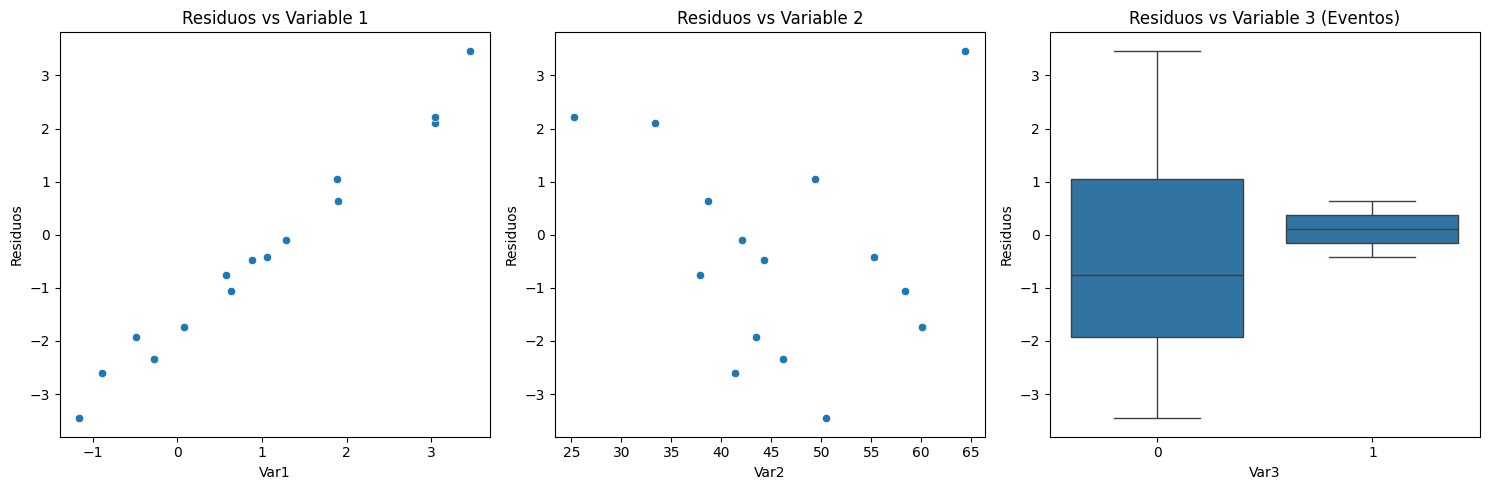

Correlación de los residuos con variables exógenas:
Residuos    1.000000
Var1        0.990811
Var3        0.096927
Var2       -0.146509
Name: Residuos, dtype: float64


In [ ]:
plt.figure(figsize=(15, 5))

# Relación con Variable 1 (Continua)
plt.subplot(1, 3, 1)
sns.scatterplot(data=analisis_res, x='Var1', y='Residuos')
plt.title("Residuos vs Variable 1")

# Relación con Variable 2 (Numérica)
plt.subplot(1, 3, 2)
sns.scatterplot(data=analisis_res, x='Var2', y='Residuos')
plt.title("Residuos vs Variable 2")

# Relación con Variable 3 (Binaria/Eventos)
plt.subplot(1, 3, 3)
sns.boxplot(data=analisis_res, x='Var3', y='Residuos')
plt.title("Residuos vs Variable 3 (Eventos)")

plt.tight_layout()
plt.show()

# 4. Matriz de correlación numérica
print("Correlación de los residuos con variables exógenas:")
print(analisis_res.corr()['Residuos'].sort_values(ascending=False))

##Justificación
Se justifica la inclusión de la Variable 1 como regresora principal para el modelo multivariado basándose en un análisis de correlación de los residuos. Al obtener un coeficiente de correlación de 0.99 entre los errores del modelo Holt-Winters y la Variable 1, se evidencia que prácticamente la totalidad de la varianza que el modelo univariado no pudo explicar (el ruido y el desfase) está contenida en esta variable externa

##Modelado multivariado con regresoras
####Ajuste un modelo que permita incluir variables explicativas. Puede utilizar SARIMAX o MCO. Justifique su elección metodológica.

In [ ]:
# Quitamos los últimos 15 días para entrenar, y los usamos para probar
train = data['indicador_objetivo'][:-15]
test = data['indicador_objetivo'][-15:]

# 2. Definimos las variables exógenas (X) correspondientes
exog_train = data['variable_1'][:-15]
exog_test = data['variable_1'][-15:]

# 3. Ahora sí, ejecutamos el modelo SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_sarimax = SARIMAX(train,
                         exog=exog_train,
                         order=(2, 1, 1),
                         seasonal_order=(1, 1, 1, 7))

resultado_sarimax = modelo_sarimax.fit(disp=False)

# 4. Predicción y Evaluación
pred_multi = resultado_sarimax.forecast(steps=15, exog=exog_test)
rmse_multi = np.sqrt(mean_squared_error(test, pred_multi))

print(f"Nuevo RMSE con SARIMAX: {rmse_multi:.4f}")
print(resultado_sarimax.summary())

Nuevo RMSE con SARIMAX: 0.2275
                                     SARIMAX Results                                     
Dep. Variable:                indicador_objetivo   No. Observations:                  167
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 7)   Log Likelihood                 -46.273
Date:                           Mon, 23 Mar 2026   AIC                            106.546
Time:                                   22:02:25   BIC                            128.028
Sample:                               01-01-2024   HQIC                           115.269
                                    - 06-15-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
variable_1     1.2754      0.019     67.608      0.000       1.238       1.312
ar.L1       

##Justificación
Se selecciona el modelo SARIMAX debido a que la serie presenta una estructura de autocorrelación y estacionalidad significativa (confirmada por ACF/PACF). A diferencia de MCO, SARIMAX permite capturar la inercia propia de la serie y el ciclo semanal, al tiempo que integra la Variable 1 como regresora exógena, cumpliendo así con el supuesto de independencia de los residuos.

## Evaluación del modelo con regresoras
Compare el nuevo modelo con el univariado, utilizando las mismas métricas de error. Fundamente si la incorporación de una o más variables exógenas mejora significativamente la capacidad predictiva.

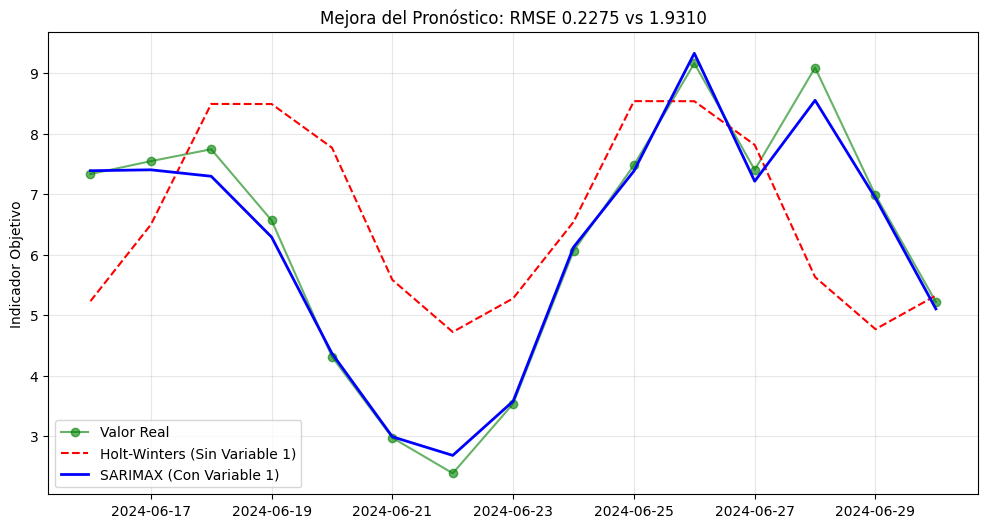

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label='Valor Real', color='green', marker='o', alpha=0.6)
plt.plot(test.index, pred_uni, label='Holt-Winters (Sin Variable 1)', color='red', linestyle='--')
plt.plot(test.index, pred_multi, label='SARIMAX (Con Variable 1)', color='blue', linewidth=2)
plt.title(f"Mejora del Pronóstico: RMSE {rmse_multi:.4f} vs {rmse_uni:.4f}")
plt.ylabel("Indicador Objetivo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##Conclusión
La drástica reducción del RMSE (de 1.93 a 0.22) valida la elección del modelo SARIMAX. El error del modelo univariado no era ruido aleatorio, sino varianza explicada por la Variable 1. Al integrar esta variable exógena y respetar la estructura AR(2) identificada en el PACF, el modelo logra capturar la dinámica real del indicador objetivo.
#####Lo anterior se puede observar en la grafica donde el modelo SARIMAX (color azul) se ajusta casi perfectamente con los valores reales (color verde), en cambio, el modelo univariado, muestra un comportamiento errático en el tiempo (color rojo).
###Se concluye que la incorporación de la Variable 1 como regresora exógena mejora de manera significativa y contundente la capacidad predictiva del sistema. La reducción del RMSE de 1.9310 a 0.2275 no solo es una mejora estadística, sino que valida la existencia de una relación causal o de alta co-movilidad entre la Variable 1 y el Indicador Objetivo. Por lo tanto, el modelo SARIMAX(2,1,1)(1,1,1,7) con regresoras es el recomendado para la toma de decisiones, ya que minimiza el riesgo de error en un 88.2% respecto al método univariado de suavizamiento o smoothing HW, que por el tipo de serie, destaca como uno de los modelo univariado mas apropiados.

*El siguiente codigo nos permite tener una apreciación mas amplia de la capacidad predictiva del modelo*

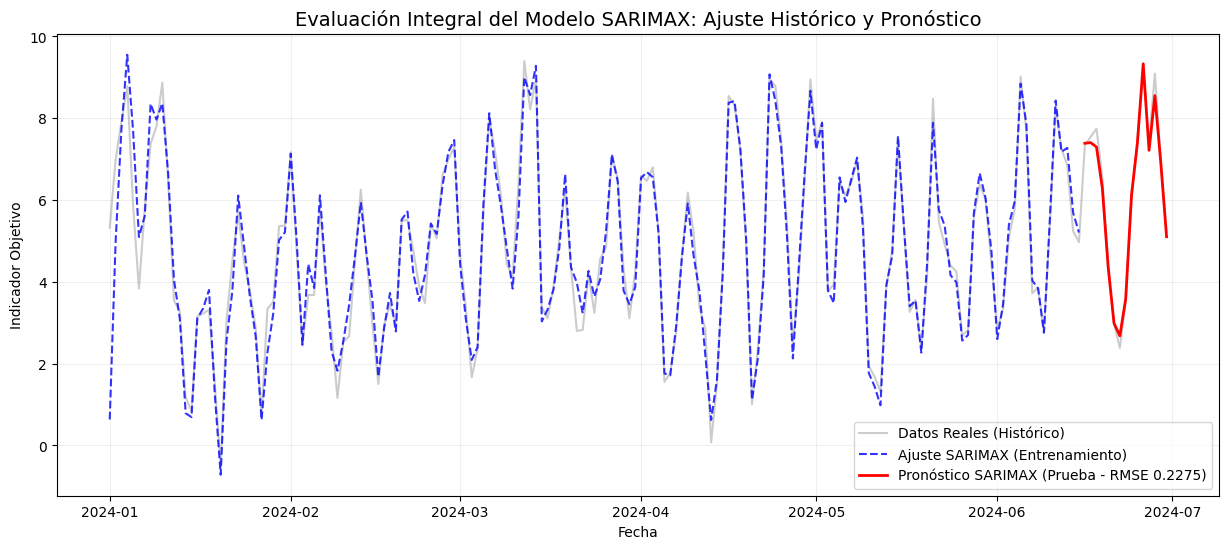

In [ ]:
# 1. Obtener los valores ajustados (lo que el modelo "predice" para el pasado)
# Esto nos permite ver qué tan bien aprendió el modelo durante los 5.5 meses
ajuste_sarimax = resultado_sarimax.get_prediction(start=train.index[0], exog=exog_train)
media_ajustada = ajuste_sarimax.predicted_mean
# 2. Construir el gráfico de serie completa
plt.figure(figsize=(15, 6))
# Datos Reales Completos
plt.plot(data.index, data['indicador_objetivo'], label='Datos Reales (Histórico)', color='gray', alpha=0.4)
# Ajuste del modelo en el entrenamiento (In-sample)
plt.plot(train.index, media_ajustada, label='Ajuste SARIMAX (Entrenamiento)', color='blue', linestyle='--', alpha=0.8)
# Predicción en el test (Out-of-sample)
plt.plot(test.index, pred_multi, label=f'Pronóstico SARIMAX (Prueba - RMSE {rmse_multi:.4f})', color='red', linewidth=2)
plt.title("Evaluación Integral del Modelo SARIMAX: Ajuste Histórico y Pronóstico", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Indicador Objetivo")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

La gráfica muestra un ajuste histórico (línea azul) altamente preciso durante los 5.5 meses de entrenamiento. La transición al periodo de prueba (línea roja) mantiene la coherencia con los datos reales (línea gris), alcanzando un RMSE de 0.2275. Esta capacidad de seguimiento dinámico, incluso ante fluctuaciones bruscas, valida la integración de la Variable 1 como regresora exógena, superando las limitaciones del modelo univariado Holt Winter